In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


df = pd.read_csv("../data/processed/cleaned_properties.csv")

print(f" Συνολικός Αριθμός Ακινήτων: {len(df)}")
print(f" Καλυπτόμενες Περιοχές: {df['suburb'].nunique()}")
print(f" Μέσο Ενοίκιο Αττικής: €{round(df['price'].mean(), 2)}")
print(f" Μέση Τιμή ανά τ.μ.: €{round(df['price_per_sqm'].mean(), 2)}/m²\n")

df[['price', 'sqm', 'price_per_sqm', 'bedrooms', 'year_built']].describe().T

 Συνολικός Αριθμός Ακινήτων: 4162
 Καλυπτόμενες Περιοχές: 76
 Μέσο Ενοίκιο Αττικής: €1025.79
 Μέση Τιμή ανά τ.μ.: €12.84/m²



,count,mean,std,min,25%,50%,75%,max
price,4162.0,1025.788803,579.530888,300.00,650.00,850.00,1200.00,4000.00
sqm,4162.0,83.115810,39.892376,20.00,54.00,76.00,102.00,300.00
price_per_sqm,4162.0,12.841920,4.257265,4.91,9.72,12.05,15.29,31.58
bedrooms,4162.0,1.852235,0.869263,0.00,1.00,2.00,2.00,10.00
year_built,4162.0,1983.778712,17.715038,1900.00,1972.00,1980.00,1995.00,2026.00


C:\Users\zonga\AppData\Local\Temp\ipykernel_9436\2276605112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top15, x='price_per_sqm', y='suburb', palette='viridis', order=top_15_suburbs)


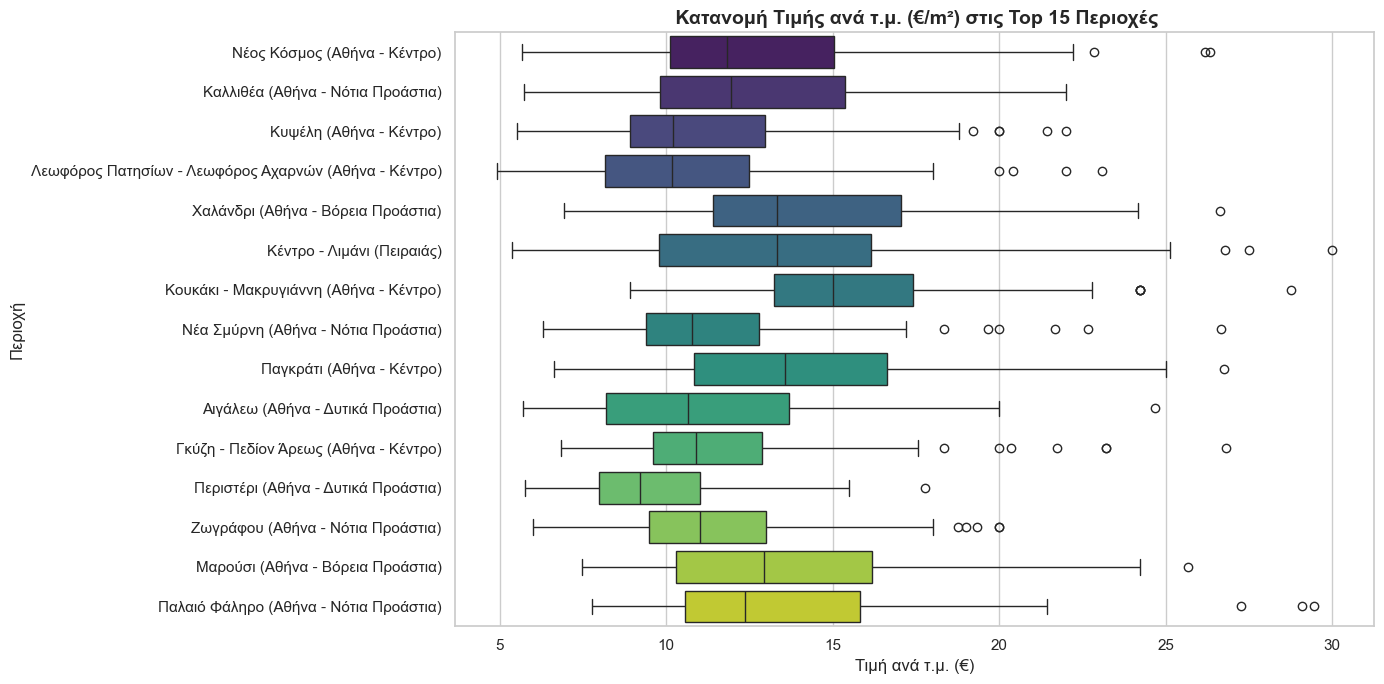

In [19]:
# top 5 areas 
top_15_suburbs = df['suburb'].value_counts().head(15).index
df_top15 = df[df['suburb'].isin(top_15_suburbs)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top15, x='price_per_sqm', y='suburb', palette='viridis', order=top_15_suburbs)
plt.title(' Κατανομή Τιμής ανά τ.μ. (€/m²) στις Top 15 Περιοχές', fontsize=14, fontweight='bold')
plt.xlabel('Τιμή ανά τ.μ. (€)')
plt.ylabel('Περιοχή')
plt.tight_layout()
plt.show()

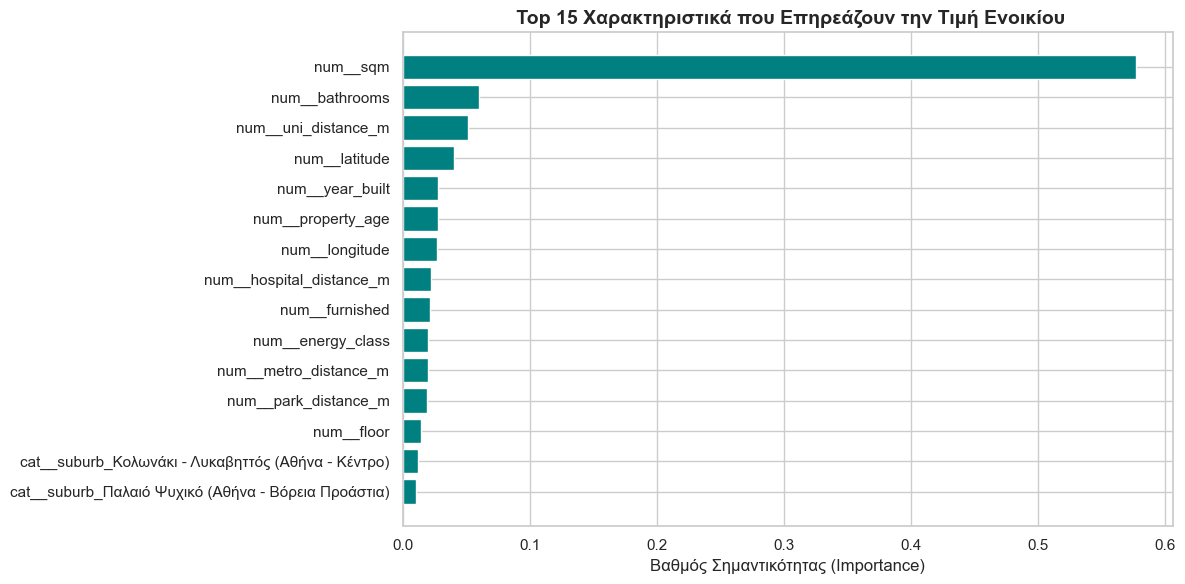

In [3]:
import joblib


model = joblib.load("../models/price_model.pkl")


if hasattr(model, 'named_steps'):
    regressor = model.named_steps['regressor']
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
else:
    regressor = model
    feature_names = [col for col in df.columns if col not in ['price', 'price_per_sqm', 'id']]

importances = regressor.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15

plt.figure(figsize=(12, 6))
plt.title(" Top 15 Χαρακτηριστικά που Επηρεάζουν την Τιμή Ενοικίου", fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Βαθμός Σημαντικότητας (Importance)')
plt.tight_layout()
plt.show()

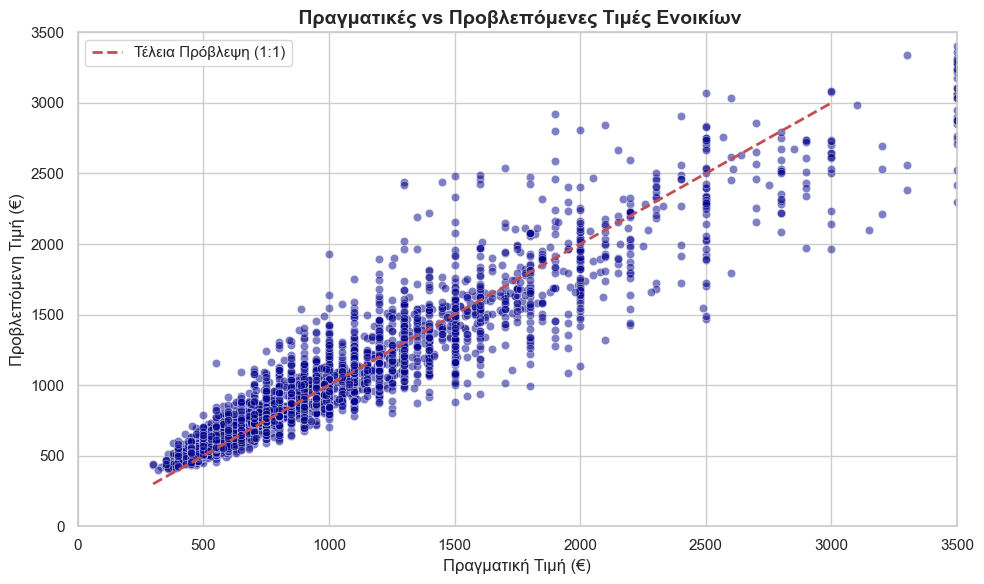

In [17]:
# Προβλέψεις για όλο το dataset
X = df.drop(columns=['price', 'price_per_sqm', 'id'], errors='ignore')
df['predicted_price'] = model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='predicted_price', alpha=0.5, color='darkblue')
plt.plot([df['price'].min(), 3000], [df['price'].min(), 3000], 'r--', lw=2, label='Τέλεια Πρόβλεψη (1:1)')
plt.xlim(0, 3500)
plt.ylim(0, 3500)
plt.xlabel('Πραγματική Τιμή (€)')
plt.ylabel('Προβλεπόμενη Τιμή (€)')
plt.title(' Πραγματικές vs Προβλεπόμενες Τιμές Ενοικίων', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:

print(" ΟΝΟΜΑΤΑ ΣΤΗΛΩΝ DATASET:")
print(list(df.columns))
print("-" * 50)


missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print(" Δεν υπάρχουν ελλείπουσες τιμές (Missing Values) στο dataset!")
else:
    print(" Ελλείπουσες τιμές ανά στήλη:")
    print(missing_values)

 ΟΝΟΜΑΤΑ ΣΤΗΛΩΝ DATASET:
['id', 'price', 'sqm', 'bedrooms', 'bathrooms', 'floor', 'year_built', 'energy_class', 'suburb', 'area', 'latitude', 'longitude', 'elevator', 'renovated', 'furnished', 'heating_type', 'price_per_sqm', 'property_age', 'metro_distance_m', 'uni_distance_m', 'hospital_distance_m', 'park_distance_m', 'predicted_price']
--------------------------------------------------
 Δεν υπάρχουν ελλείπουσες τιμές (Missing Values) στο dataset!


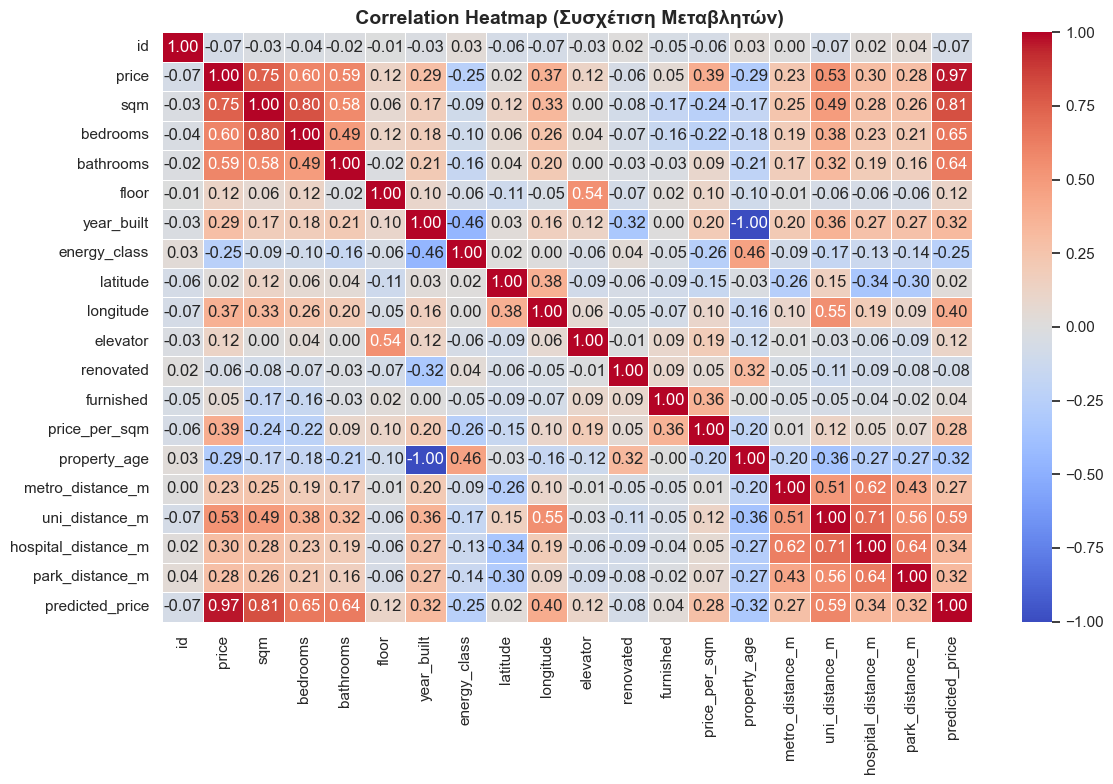

Συσχέτιση μεταβλητών με την τιμή ενοικίου (Price):
price                  1.000000
predicted_price        0.966203
sqm                    0.747066
bedrooms               0.595693
bathrooms              0.593603
uni_distance_m         0.528964
price_per_sqm          0.390960
longitude              0.370577
hospital_distance_m    0.296378
year_built             0.288625
park_distance_m        0.283425
metro_distance_m       0.226724
elevator               0.123742
floor                  0.122464
furnished              0.048599
latitude               0.017217
renovated             -0.057428
id                    -0.068867
energy_class          -0.245581
property_age          -0.288625
Name: price, dtype: float64


In [11]:

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Correlation Matrix
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title(" Correlation Heatmap (Συσχέτιση Μεταβλητών)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("Συσχέτιση μεταβλητών με την τιμή ενοικίου (Price):")
print(corr_matrix['price'].sort_values(ascending=False))

In [15]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

#  Φόρτωση του αποθηκευμένου/διορθωμένου μοντέλου
model = joblib.load("../models/price_model.pkl")

#  Προετοιμασία των δεδομένων
X = df.drop(columns=['price', 'price_per_sqm', 'id'], errors='ignore')
y = df['price']

#  Διαχωρισμός με το ίδιο random_state (42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#  Υπολογισμός Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(" ΕΛΕΓΧΟΣ OVERFITTING ")
print(f" Train R²: {train_r2*100:.2f}%  |  Test R²: {test_r2*100:.2f}%")
print(f" Train MAE: €{train_mae:.2f}     |  Test MAE: €{test_mae:.2f}")

# Αξιολόγηση
diff_r2 = train_r2 - test_r2
if diff_r2 > 0.15:
    print("\n ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Υπάρχει πιθανότητα Overfitting!")
else:
    print("\n ΚΑΛΟ RESULT: Το μοντέλο έχει καλό Generalization!")

 ΕΛΕΓΧΟΣ OVERFITTING 
 Train R²: 91.10%  |  Test R²: 78.83%
 Train MAE: €109.62     |  Test MAE: €157.88

 ΚΑΛΟ RESULT: Το μοντέλο έχει καλό Generalization!


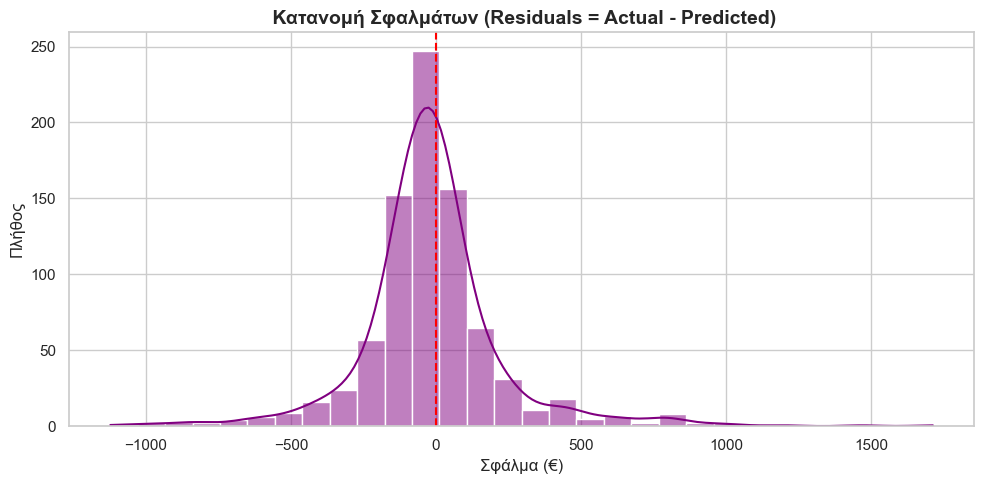

In [16]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title(" Κατανομή Σφαλμάτων (Residuals = Actual - Predicted)", fontsize=14, fontweight='bold')
plt.xlabel("Σφάλμα (€)")
plt.ylabel("Πλήθος")
plt.tight_layout()
plt.show()